In [1]:
import pandas as pd
import numpy as np
from scipy import stats

In [2]:
df = pd.read_csv("../data/Sample - Superstore.csv", encoding="latin1")
df.head()

FileNotFoundError: [Errno 2] No such file or directory: '../data/Sample - Superstore.csv'

In [3]:
import os
print(os.getcwd())

C:\Users\S LAXMI VYSHNAVI


In [4]:
import pandas as pd

df = pd.read_csv(r"C:\Users\S LAXMI VYSHNAVI\Downloads\Sample - Superstore.csv", encoding="latin1")
df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,3,CA-2016-138688,6/12/2016,6/16/2016,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
3,4,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
4,5,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164


In [5]:
df["Sales"].describe()

count     9994.000000
mean       229.858001
std        623.245101
min          0.444000
25%         17.280000
50%         54.490000
75%        209.940000
max      22638.480000
Name: Sales, dtype: float64

In [6]:
print("Median:", df["Sales"].median())

Median: 54.489999999999995


In [7]:
print(df["Category"].mode())

0    Office Supplies
Name: Category, dtype: object


In [8]:
print("Skewness:", df["Sales"].skew())

Skewness: 12.97275234181623


In [9]:
tech = df[df["Category"]=="Technology"]["Sales"]
furniture = df[df["Category"]=="Furniture"]["Sales"]

t_stat, p_val = stats.ttest_ind(tech, furniture)

print("T Statistic:", t_stat)
print("P Value:", p_val)

T Statistic: 3.8430849029195886
P Value: 0.0001233995294543413


In [10]:
if p_val < 0.05:
    print("Significant Difference")
else:
    print("No Significant Difference")

Significant Difference


In [11]:
df["Order Date"] = pd.to_datetime(df["Order Date"])

In [12]:
ts = df.groupby("Order Date")["Sales"].sum()
ts.head()

Order Date
2014-01-03      16.448
2014-01-04     288.060
2014-01-05      19.536
2014-01-06    4407.100
2014-01-07      87.158
Name: Sales, dtype: float64

In [13]:
monthly_sales = ts.resample("M").sum()
monthly_sales.head()

C:\Users\S LAXMI VYSHNAVI\AppData\Local\Temp\ipykernel_16920\2643710872.py:1: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  monthly_sales = ts.resample("M").sum()


Order Date
2014-01-31    14236.895
2014-02-28     4519.892
2014-03-31    55691.009
2014-04-30    28295.345
2014-05-31    23648.287
Freq: ME, Name: Sales, dtype: float64

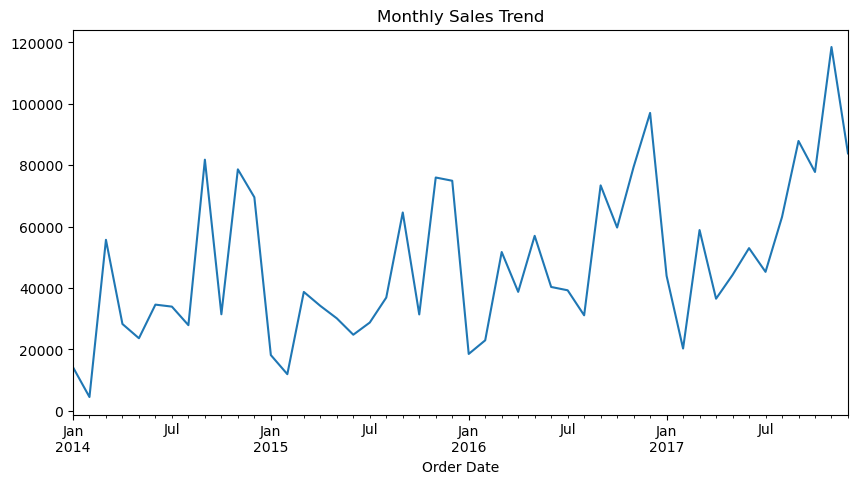

In [14]:
import matplotlib.pyplot as plt

monthly_sales.plot(figsize=(10,5))
plt.title("Monthly Sales Trend")
plt.show()

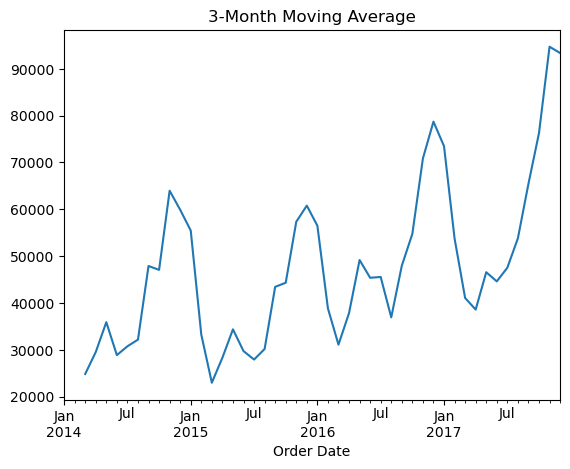

In [15]:
monthly_sales.rolling(3).mean().plot()
plt.title("3-Month Moving Average")
plt.show()

In [16]:
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

In [17]:
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

In [18]:
cluster_data = df[["Sales", "Profit", "Quantity"]]

In [19]:
scaler = StandardScaler()
scaled_data = scaler.fit_transform(cluster_data)

In [20]:
inertia = []

for i in range(1, 11):
    kmeans = KMeans(n_clusters=i, random_state=42)
    kmeans.fit(scaled_data)
    inertia.append(kmeans.inertia_)

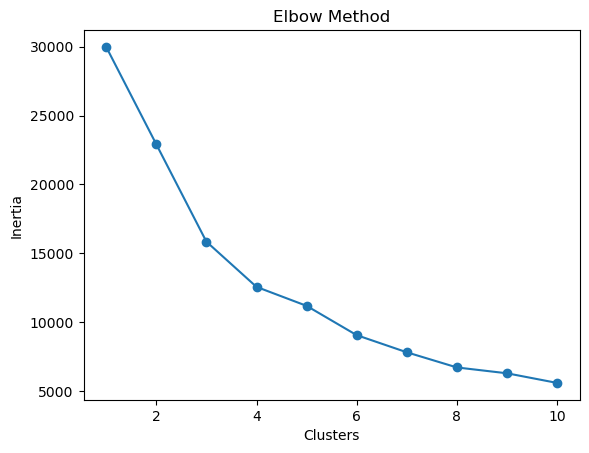

In [21]:
import matplotlib.pyplot as plt

plt.plot(range(1,11), inertia, marker='o')
plt.xlabel("Clusters")
plt.ylabel("Inertia")
plt.title("Elbow Method")
plt.show()

In [22]:
kmeans = KMeans(n_clusters=4, random_state=42)

df["Cluster"] = kmeans.fit_predict(scaled_data)

In [23]:
from sklearn.decomposition import PCA

In [24]:
pca = PCA(n_components=2)

pca_data = pca.fit_transform(scaled_data)

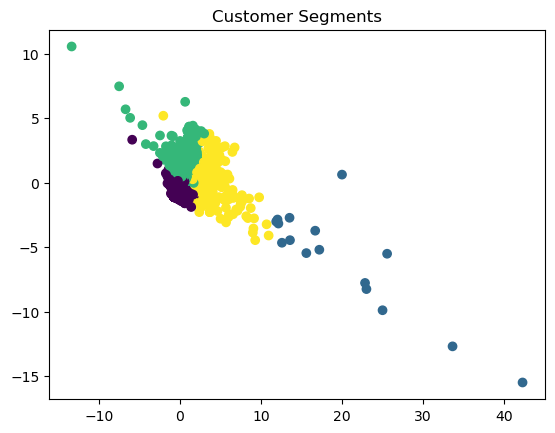

In [25]:
plt.scatter(
    pca_data[:,0],
    pca_data[:,1],
    c=df["Cluster"]
)

plt.title("Customer Segments")
plt.show()

In [26]:
X = df[["Profit", "Quantity", "Discount"]]

y = df["Sales"]

In [27]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

In [28]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()

model.fit(X_train, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [29]:
y_pred = model.predict(X_test)

In [30]:
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
import numpy as np

In [31]:
print("R2 Score:", r2_score(y_test, y_pred))
print("MAE:", mean_absolute_error(y_test, y_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred)))

R2 Score: -0.15181720106064578
MAE: 245.07556984450244
RMSE: 824.8499599151128


In [32]:
importance = pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": model.coef_
})

importance.sort_values(
    by="Coefficient",
    ascending=False
)

,Feature,Coefficient
2,Discount,249.571780
1,Quantity,41.550264
0,Profit,1.561674


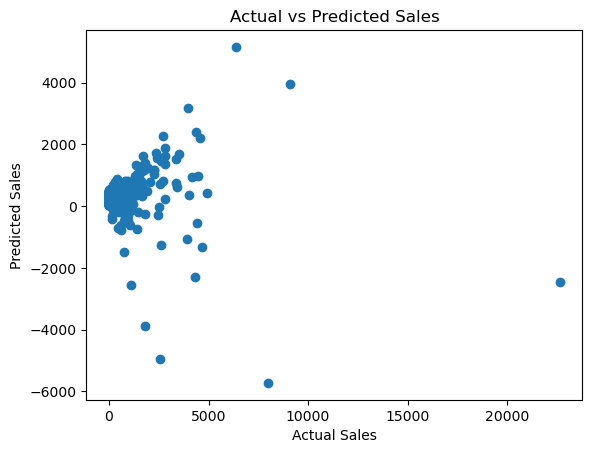

In [33]:
import matplotlib.pyplot as plt

plt.scatter(y_test, y_pred)
plt.xlabel("Actual Sales")
plt.ylabel("Predicted Sales")
plt.title("Actual vs Predicted Sales")
plt.show()